1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. LOAD DATA

In [2]:
df = pd.read_csv("../data/raw/customer_churn_dataset-testing-master.csv")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


3. BASIC INFO

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


4. CLEAN COLUMN NAMES

In [4]:
df.columns = df.columns.str.lower().str.strip()
df.columns = df.columns.str.replace(" ", "_")

df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

5. MISSING VALUES CHECK

In [5]:
df.isnull().sum()

customerid           0
age                  0
gender               0
tenure               0
usage_frequency      0
support_calls        0
payment_delay        0
subscription_type    0
contract_length      0
total_spend          0
last_interaction     0
churn                0
dtype: int64

6. TARGET DISTRIBUTION

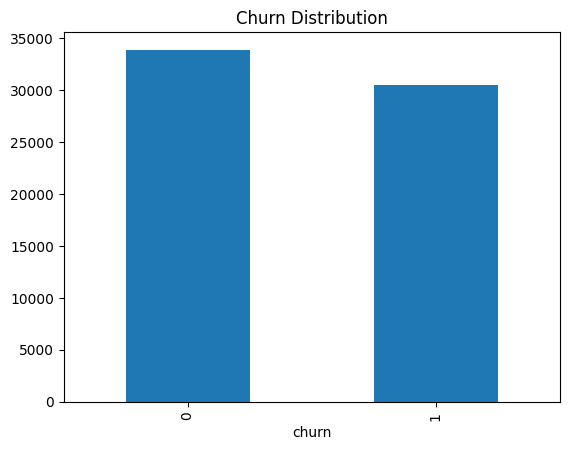

In [6]:
if "churn" in df.columns:
    df["churn"].value_counts().plot(kind="bar")
    plt.title("Churn Distribution")
    plt.show()

7. FEATURE INSIGHT

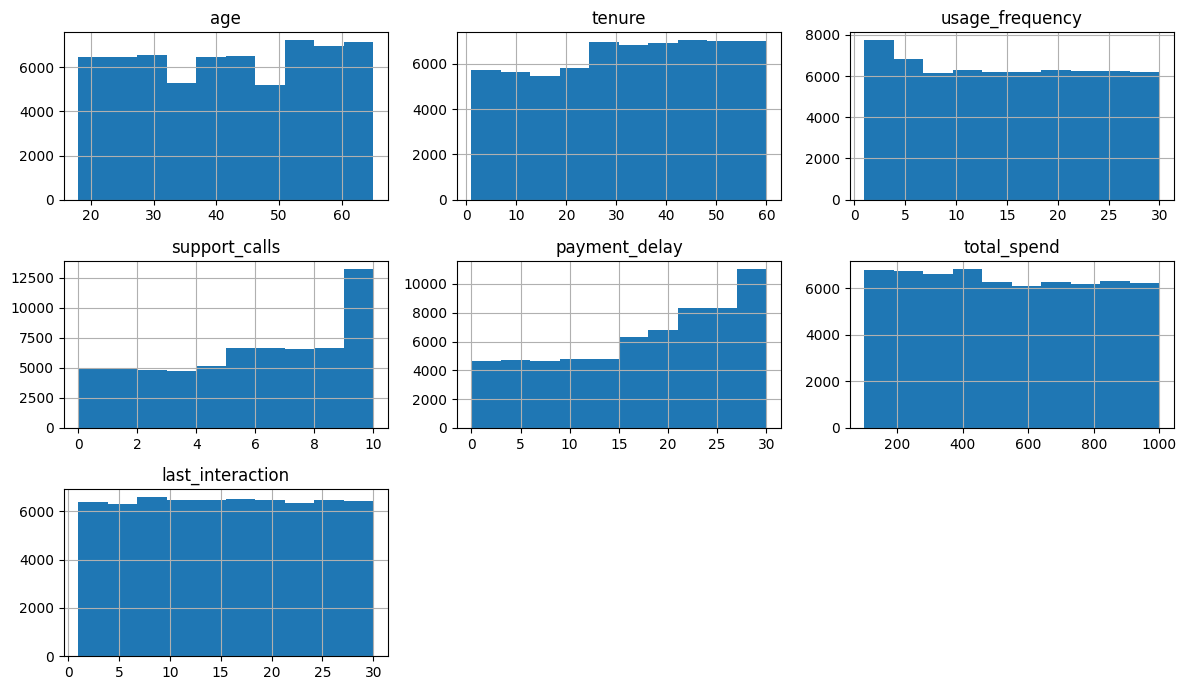

In [10]:
important_cols = [
    "age",
    "tenure",
    "usage_frequency",
    "support_calls",
    "payment_delay",
    "total_spend",
    "last_interaction"
]

df[important_cols].hist(figsize=(12, 7))
plt.tight_layout()
plt.show()

8. CORRELATION MATRIX

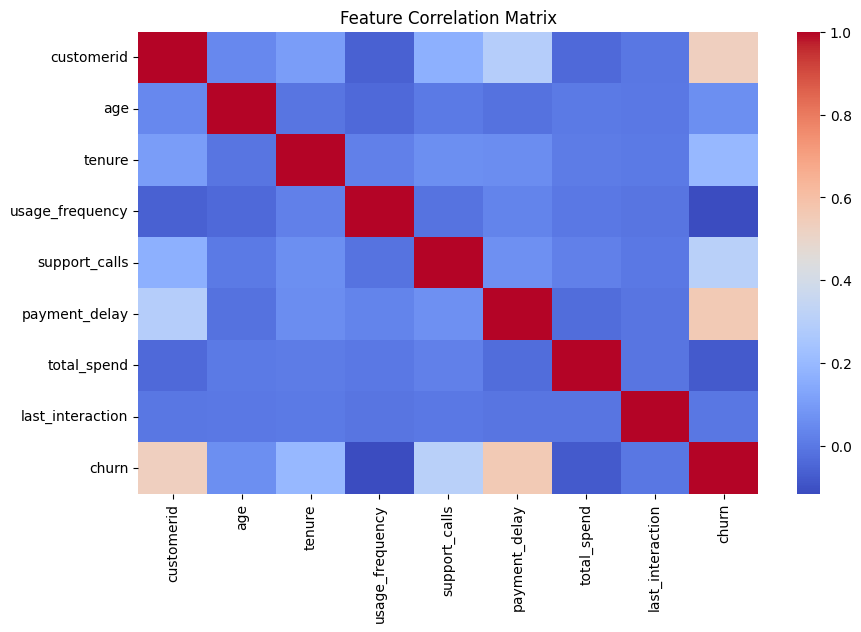

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

9. CHURN VS FEATURES

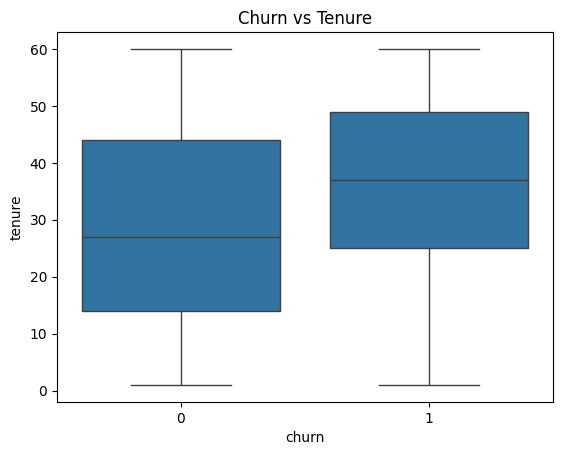

In [11]:
if "churn" in df.columns:
    sns.boxplot(x="churn", y="tenure", data=df)
    plt.title("Churn vs Tenure")
    plt.show()

10. FEATURE ENGINEERING TEST

In [13]:
df["recency_score"] = 1 / (df["last_interaction"] + 1)

df["engagement_score"] = (
    df["usage_frequency"] * df["support_calls"]
)

df[["recency_score", "engagement_score"]].head()

,recency_score,engagement_score
0,0.100000,56
1,0.047619,196
2,0.045455,20
3,0.052632,60
4,0.052632,216


11. FINAL INSIGHT

In [14]:
print("Dataset shape:", df.shape)
print("Churn rate:", df["churn"].mean())

Dataset shape: (64374, 14)
Churn rate: 0.47368502811694163
